In [1]:
import sys
sys.path.append('../')

import starry.utils.env

In [2]:
import yaml


scores = yaml.safe_load(open('../../imslp-mining/spartitos/paraff-paragraph-translator.yaml', 'r'))
scores

{'meta': {'saveTime': datetime.datetime(2024, 12, 7, 14, 41, 8, 784000, tzinfo=datetime.timezone.utc),
  'models': {'translator': '20231102-paraff-graph_trans-pos-1102-tp-l4+6-d256/model_790_acc_9.807e-01',
   'beamSize': None}},
 'scores': {'17007-02104-p0.[0-25]': {'_descriptors': '#double-staff #polyvoice #bach #baroque',
   'm0pre_n-1,27': 'BOS',
   'm0_n0,26': 'BOM K1 TN4 TD4 S1 Cg Md b Osup D16 VB\nS2 Cf d Osub D16 Rest EOM',
   'm1_n1,25': 'BOM K1 TN4 TD4 S1 Cg Mu b Osup D8 Dot Bl c D16 Br c D8 Dot Bl b D32 c D32 Br d D4 Etie d D16 Bl d D16 f As D16 g D16 Br VB\nS2 Cf Mu g D16 Bl b D16 S1 Cg Md d D16 EslurL g D16 Br g D16 Bl g D16 f As D16 e D16 Br e D16 Rest d D16 Bl f As D16 g D16 Br EslurL g b D4 Etie VB\nS2 Cf Md g D4 a D4 b D4 Dot b D8 EOM',
   'm2_n2,24': 'BOM K1 TN4 TD4 S1 Cg Mu e Osup D16 Bl g D16 d D16 g D16 Br c Osub D16 Bl b D16 c D16 a Osup D16 Br c Osub D16 Bl b D16 a D16 g D16 Br b D4 Etie VB\nS1 Cg Md g Osup D4 Dot f As D8 e D8 Rest b D8 Bl d D8 g D8 Br VB\nS2 Cf 

In [3]:
import os

from starry.utils.config import Configuration


TRAINING_DIR = os.environ.get('TRAINING_DIR')

config = Configuration.createOrLoad(os.path.join(TRAINING_DIR, 'paraff/20241113-paraff-vae-shared-241104-d256-l4/'))
config.data

{'_vocab': 'PAD,MSUM,BOS,EOS,BOM,EOM,VB,S1,S2,S3,Cg,Cf,Cc,K0,K1,K2,K3,K4,K5,K6,K_1,K_2,K_3,K_4,K_5,K_6,TN1,TN2,TN3,TN4,TN5,TN6,TN7,TN8,TN9,TN10,TN11,TN12,TD2,TD4,TD8,TD16,a,b,c,d,e,f,g,As,Af,Ass,Aff,Osup,Osub,O0,Ova,Ovb,D1,D2,D4,D8,D16,D32,D64,D128,D256,Dot,Bl,Br,Mu,Md,Rest,RSpace,W2,W3,W4,W5,W6,W7,W8,W9,W10,W12,W16,W24,W32,Wx,W,G,TM8,TM16,TM32,TM64,TM128,TM256,TC8,TC16,TC32,TC64,TC128,TC256,EslurL,EslurR,Etie,Earp,Etr,Efer,Esf,Est,Estm,Eac,Emor,Epr,Eturn,Epor,Eten,Emar,Ecre,Edim,Ecds,EDf,EDp,EDm,EDr,EDs,EDz,#full,#non-tremolo,#non-grace,#non-octave-shift,#non-timewarp,#monovoice,#double-staff,#non-dot,#8th-rhythm,#16th-rhythm,#dot,#triple-staff,#polyvoice,#4th-rhythm,#single-staff,#timewarp,#octave-shift,#grace,#32th-rhythm,#complicated,#cross-staves,#2nd-rhythm,#1st-rhythm,#tremolo,#partial,#64th-rhythm',
 'best': 'model_23903_loss_2.460e-02.chkpt',
 'data': {'args': {'descriptor_drop': 0.3,
   'descriptor_drop_sigma': 0.5,
   'n_seq': 360},
  'args_variant': {1: {'descriptor_drop': 

In [4]:
tokens = config['_vocab'].split(',')
tokens

['PAD',
 'MSUM',
 'BOS',
 'EOS',
 'BOM',
 'EOM',
 'VB',
 'S1',
 'S2',
 'S3',
 'Cg',
 'Cf',
 'Cc',
 'K0',
 'K1',
 'K2',
 'K3',
 'K4',
 'K5',
 'K6',
 'K_1',
 'K_2',
 'K_3',
 'K_4',
 'K_5',
 'K_6',
 'TN1',
 'TN2',
 'TN3',
 'TN4',
 'TN5',
 'TN6',
 'TN7',
 'TN8',
 'TN9',
 'TN10',
 'TN11',
 'TN12',
 'TD2',
 'TD4',
 'TD8',
 'TD16',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'As',
 'Af',
 'Ass',
 'Aff',
 'Osup',
 'Osub',
 'O0',
 'Ova',
 'Ovb',
 'D1',
 'D2',
 'D4',
 'D8',
 'D16',
 'D32',
 'D64',
 'D128',
 'D256',
 'Dot',
 'Bl',
 'Br',
 'Mu',
 'Md',
 'Rest',
 'RSpace',
 'W2',
 'W3',
 'W4',
 'W5',
 'W6',
 'W7',
 'W8',
 'W9',
 'W10',
 'W12',
 'W16',
 'W24',
 'W32',
 'Wx',
 'W',
 'G',
 'TM8',
 'TM16',
 'TM32',
 'TM64',
 'TM128',
 'TM256',
 'TC8',
 'TC16',
 'TC32',
 'TC64',
 'TC128',
 'TC256',
 'EslurL',
 'EslurR',
 'Etie',
 'Earp',
 'Etr',
 'Efer',
 'Esf',
 'Est',
 'Estm',
 'Eac',
 'Emor',
 'Epr',
 'Eturn',
 'Epor',
 'Eten',
 'Emar',
 'Ecre',
 'Edim',
 'Ecds',
 'EDf',
 'EDp',
 'EDm',
 'EDr',
 'EDs'

In [5]:
T2I = dict([(t, i) for i, t in enumerate(tokens)])
T2I

{'PAD': 0,
 'MSUM': 1,
 'BOS': 2,
 'EOS': 3,
 'BOM': 4,
 'EOM': 5,
 'VB': 6,
 'S1': 7,
 'S2': 8,
 'S3': 9,
 'Cg': 10,
 'Cf': 11,
 'Cc': 12,
 'K0': 13,
 'K1': 14,
 'K2': 15,
 'K3': 16,
 'K4': 17,
 'K5': 18,
 'K6': 19,
 'K_1': 20,
 'K_2': 21,
 'K_3': 22,
 'K_4': 23,
 'K_5': 24,
 'K_6': 25,
 'TN1': 26,
 'TN2': 27,
 'TN3': 28,
 'TN4': 29,
 'TN5': 30,
 'TN6': 31,
 'TN7': 32,
 'TN8': 33,
 'TN9': 34,
 'TN10': 35,
 'TN11': 36,
 'TN12': 37,
 'TD2': 38,
 'TD4': 39,
 'TD8': 40,
 'TD16': 41,
 'a': 42,
 'b': 43,
 'c': 44,
 'd': 45,
 'e': 46,
 'f': 47,
 'g': 48,
 'As': 49,
 'Af': 50,
 'Ass': 51,
 'Aff': 52,
 'Osup': 53,
 'Osub': 54,
 'O0': 55,
 'Ova': 56,
 'Ovb': 57,
 'D1': 58,
 'D2': 59,
 'D4': 60,
 'D8': 61,
 'D16': 62,
 'D32': 63,
 'D64': 64,
 'D128': 65,
 'D256': 66,
 'Dot': 67,
 'Bl': 68,
 'Br': 69,
 'Mu': 70,
 'Md': 71,
 'Rest': 72,
 'RSpace': 73,
 'W2': 74,
 'W3': 75,
 'W4': 76,
 'W5': 77,
 'W6': 78,
 'W7': 79,
 'W8': 80,
 'W9': 81,
 'W10': 82,
 'W12': 83,
 'W16': 84,
 'W24': 85,
 'W32': 86,


In [38]:
s0 = scores['scores']['17007-02104-p0.[0-25]']
s0 = [m for m in s0.values() if m.startswith('BOM')]
s0

['BOM K1 TN4 TD4 S1 Cg Md b Osup D16 VB\nS2 Cf d Osub D16 Rest EOM',
 'BOM K1 TN4 TD4 S1 Cg Mu b Osup D8 Dot Bl c D16 Br c D8 Dot Bl b D32 c D32 Br d D4 Etie d D16 Bl d D16 f As D16 g D16 Br VB\nS2 Cf Mu g D16 Bl b D16 S1 Cg Md d D16 EslurL g D16 Br g D16 Bl g D16 f As D16 e D16 Br e D16 Rest d D16 Bl f As D16 g D16 Br EslurL g b D4 Etie VB\nS2 Cf Md g D4 a D4 b D4 Dot b D8 EOM',
 'BOM K1 TN4 TD4 S1 Cg Mu e Osup D16 Bl g D16 d D16 g D16 Br c Osub D16 Bl b D16 c D16 a Osup D16 Br c Osub D16 Bl b D16 a D16 g D16 Br b D4 Etie VB\nS1 Cg Md g Osup D4 Dot f As D8 e D8 Rest b D8 Bl d D8 g D8 Br VB\nS2 Cf Md c D8 Bl b D8 Br a D4 g D4 Etie g D16 Bl f As D16 e D16 d D16 Br EOM',
 'BOM K1 TN4 TD4 S1 Cg Mu b Osup D16 Bl e D16 a Osub D16 e Osup D16 Br g Osub D16 Bl f As D16 g D16 e Osup D16 Br g Osub D16 Bl f As D16 e D16 d D16 Br e D16 Bl f As D16 g D16 f As D16 Br VB\nS1 Cg Md e D4 e D2 Dot RSpace VB\nS2 Cf a D8 Rest Mu e D8 a D4 g D8 Rest f As D8 a D4 VB\nS2 Cf Md c Osub D4 Dot c D8 d D4 Dot c D

In [39]:
m_ids = [list(map(lambda x: T2I[x], m.replace('\n', ' ').split(' '))) for m in s0]
m_ids

[[4, 14, 29, 39, 7, 10, 71, 43, 53, 62, 6, 8, 11, 45, 54, 62, 72, 5],
 [4,
  14,
  29,
  39,
  7,
  10,
  70,
  43,
  53,
  61,
  67,
  68,
  44,
  62,
  69,
  44,
  61,
  67,
  68,
  43,
  63,
  44,
  63,
  69,
  45,
  60,
  104,
  45,
  62,
  68,
  45,
  62,
  47,
  49,
  62,
  48,
  62,
  69,
  6,
  8,
  11,
  70,
  48,
  62,
  68,
  43,
  62,
  7,
  10,
  71,
  45,
  62,
  102,
  48,
  62,
  69,
  48,
  62,
  68,
  48,
  62,
  47,
  49,
  62,
  46,
  62,
  69,
  46,
  62,
  72,
  45,
  62,
  68,
  47,
  49,
  62,
  48,
  62,
  69,
  102,
  48,
  43,
  60,
  104,
  6,
  8,
  11,
  71,
  48,
  60,
  42,
  60,
  43,
  60,
  67,
  43,
  61,
  5],
 [4,
  14,
  29,
  39,
  7,
  10,
  70,
  46,
  53,
  62,
  68,
  48,
  62,
  45,
  62,
  48,
  62,
  69,
  44,
  54,
  62,
  68,
  43,
  62,
  44,
  62,
  42,
  53,
  62,
  69,
  44,
  54,
  62,
  68,
  43,
  62,
  42,
  62,
  48,
  62,
  69,
  43,
  60,
  104,
  6,
  7,
  10,
  71,
  48,
  53,
  60,
  67,
  47,
  49,
  61,
  46,
  61,
  72,


In [40]:
import torch


model = torch.load(os.path.join(TRAINING_DIR, 'paraff/20241113-paraff-vae-shared-241104-d256-l4/model_27928_loss_2.294e-02.pt'))
model.eval()
model

/tmp/ipykernel_1337282/3012235797.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(os.path.join(TRAINING_DIR, 'paraff/20241113-paraff-vae-shared-241104

RecursiveScriptModule(
  original_name=SeqShareVAEJitEnc
  (word_emb): RecursiveScriptModule(original_name=Embedding)
  (word_prj): RecursiveScriptModule(original_name=Linear)
  (latent_prj_mu): RecursiveScriptModule(original_name=Linear)
  (latent_prj_var): RecursiveScriptModule(original_name=Linear)
  (latent_emb): RecursiveScriptModule(original_name=Linear)
  (position_enc): RecursiveScriptModule(original_name=PositionalEncoding)
  (layer_norm): RecursiveScriptModule(original_name=LayerNorm)
  (attention): RecursiveScriptModule(
    original_name=AttentionStack
    (layer_stack): RecursiveScriptModule(
      original_name=ModuleList
      (0): RecursiveScriptModule(
        original_name=EncoderLayer
        (slf_attn): RecursiveScriptModule(
          original_name=MultiHeadAttention
          (w_qs): RecursiveScriptModule(original_name=Linear)
          (w_ks): RecursiveScriptModule(original_name=Linear)
          (w_vs): RecursiveScriptModule(original_name=Linear)
          (fc):

In [41]:
msums = []

for ids in m_ids:
	with torch.no_grad():
		input_ids = torch.zeros(256).long()
		input_ids[:len(ids)] = torch.as_tensor(ids).long()
		s = model(input_ids[None], torch.zeros(1))
	s /= s.norm(dim=-1)
	msums.append(s)

msums = torch.cat(msums, dim=0)
msums.shape

torch.Size([26, 256])

In [42]:
import yaml
import os


#scores = yaml.safe_load(open(os.path.expanduser('~/data/maestro-v3.0.0/midiseq.yaml'), 'r'))
#scores['2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi']
score = open('../../intelli-piano/footages/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midiseq.txt', 'r').readlines()
score

['Soft127 Sustain127 Shift1000 Shift1000 Shift580 Vel63 On71 Soft127 Shift100 Off71 Sustain95 Shift80\n',
 'Soft127 Sustain127 Shift1000 Shift310 Vel63 On71 Soft127 Shift100 Off71 Sustain63 Shift90 Vel47 On55 Shift10 Vel55 On71 Soft95 Sustain127 Shift180 On59 Sustain127 Soft95 Shift30 Off55 Soft95 Shift130 Off59 On62 Soft95 Shift120 Off62 Shift30 Vel79 On72 Shift10 Off71 Shift10 Vel59 On67 Shift30 Off72 Shift160 Vel63 On57 Vel71 On74 Sustain95 Shift20 Off67 Sustain0 Shift40 Vel79 On72 Shift60 Off74 Vel51 On74 Shift10 Off72 Shift40 Vel63 On72 Shift20 Vel59 On67 Shift10 Off74 Shift100 Off67 Shift50 On66 Shift180 Off66 Shift10 Off72 Off57 Vel71 On71 Shift40 Vel35 On64 Shift30 Off71 Vel47 On72 Shift80 Off72 Shift10 Vel71 On74 Shift30 Vel51 On59 Shift50 Off64 Shift120 Vel63 On62 Shift190 On66 Shift30 Off62 Shift140 Vel59 On67 Shift20 Off66 Sustain31 Shift150 Off59 Sustain63 Shift30 Off74 Shift10 Vel67 On71 Sustain127 Shift150 Off71 Shift20 Vel79 On74 Sustain95 Shift180 On78 Sustain95 Shift1

In [55]:
from starry.paraff.midiseq import T2I as msT2I, ID_PEDAL0


midi_seg = [[msT2I[token] for token in seg.strip().split(' ') if msT2I[token] < ID_PEDAL0] for seg in score]
#midi_seg = [[msT2I[token] for token in seg.strip().split(' ')] for seg in score]
len(midi_seg)

48

In [56]:
import os

from starry.utils.model_factory import loadModelAndWeights
from starry.utils.config import Configuration


TRAINING_DIR = os.environ.get('TRAINING_DIR')

model_midiseq = torch.load(os.path.join(TRAINING_DIR, 'paraff/20241213-midiseq-paraff-se-ly+cc241212-d256-l8-dw0.02-dp0.6/model_4252_cos_angle_8.074e-01.pt'))
#model_midiseq = torch.load(os.path.join(TRAINING_DIR, 'paraff/20241213-midiseq-paraff-se-ly+cc241212-d256-l8-dw0.02-no_blend-no_pedal/model_3210_cos_angle_8.619e-01.pt'))
model_midiseq.eval()
model_midiseq

/tmp/ipykernel_1337282/3378079004.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_midiseq = torch.load(os.path.join(TRAINING_DIR, 'paraff/20241213-midiseq-paraff-s

RecursiveScriptModule(
  original_name=SeqShareSEJitEnc
  (word_emb): RecursiveScriptModule(original_name=Embedding)
  (word_prj): RecursiveScriptModule(original_name=Linear)
  (latent_prj): RecursiveScriptModule(original_name=Linear)
  (latent_emb): RecursiveScriptModule(original_name=Linear)
  (position_enc): RecursiveScriptModule(original_name=PositionalEncoding)
  (layer_norm): RecursiveScriptModule(original_name=LayerNorm)
  (attention): RecursiveScriptModule(
    original_name=AttentionStack
    (layer_stack): RecursiveScriptModule(
      original_name=ModuleList
      (0): RecursiveScriptModule(
        original_name=EncoderLayer
        (slf_attn): RecursiveScriptModule(
          original_name=MultiHeadAttention
          (w_qs): RecursiveScriptModule(original_name=Linear)
          (w_ks): RecursiveScriptModule(original_name=Linear)
          (w_vs): RecursiveScriptModule(original_name=Linear)
          (fc): RecursiveScriptModule(original_name=Linear)
          (attention): 

In [57]:
sum_midi = []

with torch.no_grad():
	for seq in midi_seg:
		input = torch.tensor([2] + seq[:510] + [3]).long()[None]
		sum_midi.append(model_midiseq(input))

sum_midi = torch.cat(sum_midi, dim=0)
sum_midi.shape

torch.Size([48, 256])

In [58]:
sum_midi_norm = sum_midi / sum_midi.norm(dim=-1)[:, None]
sum_midi_norm.shape

torch.Size([48, 256])

In [59]:
product = torch.matmul(msums, sum_midi_norm.transpose(1, 0))
product.shape

torch.Size([26, 48])

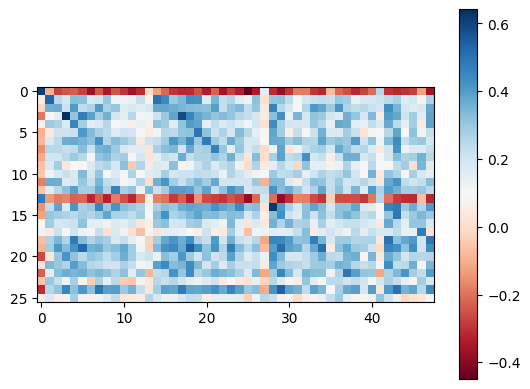

In [60]:
from matplotlib import pyplot as plt
%matplotlib inline


plt.imshow(product, cmap='RdBu')
plt.colorbar()
plt.show()